# Marketing Channel ROI Analysis

## Business Context

A mid-size B2B SaaS company runs marketing campaigns across six channels: Google Ads, LinkedIn Ads, Email, Content/SEO, Webinars, and Trade Shows. Leadership needs to understand **which channels deliver the best return on investment** and how performance varies by customer segment and region.

This analysis examines 500 campaigns spanning Q3 2024 – Q2 2025 to answer three key questions:

1. **Which channels produce the highest ROI**, and is the difference statistically significant?
2. **Does customer segment (Enterprise / Mid-Market / SMB) moderate channel effectiveness?**
3. **What campaign attributes best predict high-ROI outcomes?**

### Methodology
- Descriptive statistics and distribution analysis
- Kruskal-Wallis H-test and Dunn's post-hoc test for channel ROI comparisons
- Two-way ANOVA for channel × segment interaction effects
- OLS regression to identify ROI drivers
- Effect size estimation (Cohen's d, eta-squared)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, f_oneway
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Loading & Initial Exploration

In [2]:
df = pd.read_csv('data/campaign_performance.csv')
print(f'Dataset: {df.shape[0]} campaigns × {df.shape[1]} features')
print(f'Date range: {df["quarter"].min()} to {df["quarter"].max()}')
print(f'\nTotal marketing spend: ${df["spend_usd"].sum():,.0f}')
print(f'Total attributed revenue: ${df["revenue_usd"].sum():,.0f}')
df.head()

Dataset: 500 campaigns × 12 features
Date range: 2024-Q3 to 2025-Q2

Total marketing spend: $2,354,727
Total attributed revenue: $1,190,343,918


,campaign_id,channel,region,segment,quarter,spend_usd,impressions,clicks,leads_generated,conversions,revenue_usd,duration_days
0,CMP-0001,LinkedIn Ads,International,Enterprise,2025-Q2,2720.30,268546,5319,312,25,826182.54,30
1,CMP-0002,Google Ads,Southeast,SMB,2024-Q4,3338.24,340529,9308,890,16,77397.70,14
2,CMP-0003,Email,Southeast,Enterprise,2025-Q2,518.66,90361,2140,171,30,584300.70,7
3,CMP-0004,Email,International,Mid-Market,2024-Q4,559.90,51354,3070,468,29,280768.32,21
4,CMP-0005,Google Ads,Northeast,Mid-Market,2025-Q2,3606.52,378514,19134,2586,67,435003.85,60


In [3]:
df.info()
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Descriptive Statistics ---')
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   campaign_id      500 non-null    object 
 1   channel          500 non-null    object 
 2   region           500 non-null    object 
 3   segment          500 non-null    object 
 4   quarter          500 non-null    object 
 5   spend_usd        500 non-null    float64
 6   impressions      500 non-null    int64  
 7   clicks           500 non-null    int64  
 8   leads_generated  500 non-null    int64  
 9   conversions      500 non-null    int64  
 10  revenue_usd      500 non-null    float64
 11  duration_days    500 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 47.0+ KB

--- Missing Values ---
campaign_id        0
channel            0
region             0
segment            0
quarter            0
spend_usd          0
impressions        0
clicks           

,spend_usd,impressions,clicks,leads_generated,conversions,revenue_usd,duration_days
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,4709.45,664786.19,17415.85,2182.61,152.69,2380687.84,27.20
std,4319.55,639566.55,14714.79,2175.42,195.46,4333881.79,15.15
min,100.00,9568.00,250.00,23.00,0.00,0.00,7.00
25%,1481.14,201127.25,6448.25,733.25,36.00,345627.75,14.00
50%,3891.21,508832.00,13426.50,1513.50,87.00,820249.24,21.00
75%,6041.33,897660.75,23914.75,2811.50,186.00,2320693.62,30.00
max,25118.03,4723127.00,89287.00,12561.00,1340.00,34094632.02,60.00


## 2. Feature Engineering

We derive key performance metrics that marketing teams actually use for decision-making.

In [4]:
# Core marketing KPIs
df['roi'] = (df['revenue_usd'] - df['spend_usd']) / df['spend_usd']
df['ctr'] = df['clicks'] / df['impressions']  # Click-through rate
df['cost_per_lead'] = df['spend_usd'] / df['leads_generated'].replace(0, np.nan)
df['cost_per_conversion'] = df['spend_usd'] / df['conversions'].replace(0, np.nan)
df['lead_to_conversion_rate'] = df['conversions'] / df['leads_generated'].replace(0, np.nan)
df['revenue_per_conversion'] = df['revenue_usd'] / df['conversions'].replace(0, np.nan)
df['spend_per_day'] = df['spend_usd'] / df['duration_days']

# Flag high-ROI campaigns (top quartile)
roi_q75 = df['roi'].quantile(0.75)
df['high_roi'] = (df['roi'] >= roi_q75).astype(int)

print(f'ROI range: {df["roi"].min():.1f}x to {df["roi"].max():.1f}x')
print(f'Median ROI: {df["roi"].median():.1f}x')
print(f'High-ROI threshold (Q75): {roi_q75:.1f}x')
print(f'\nNew columns: {[c for c in df.columns if c not in ["campaign_id","channel","region","segment","quarter","spend_usd","impressions","clicks","leads_generated","conversions","revenue_usd","duration_days"]]}')

ROI range: -1.0x to 5866.8x
Median ROI: 290.4x
High-ROI threshold (Q75): 606.5x

New columns: ['roi', 'ctr', 'cost_per_lead', 'cost_per_conversion', 'lead_to_conversion_rate', 'revenue_per_conversion', 'spend_per_day', 'high_roi']


## 3. Channel Performance Overview

Before diving into statistical tests, let's visualize the distribution of ROI across channels.

In [5]:
# Summary table by channel
channel_summary = df.groupby('channel').agg(
    n_campaigns=('campaign_id', 'count'),
    total_spend=('spend_usd', 'sum'),
    total_revenue=('revenue_usd', 'sum'),
    median_roi=('roi', 'median'),
    mean_roi=('roi', 'mean'),
    median_cpl=('cost_per_lead', 'median'),
    median_cpc=('cost_per_conversion', 'median'),
    avg_conversions=('conversions', 'mean'),
).round(2)

channel_summary['overall_roi'] = (
    (channel_summary['total_revenue'] - channel_summary['total_spend']) / channel_summary['total_spend']
).round(1)

channel_summary.sort_values('median_roi', ascending=False)

,n_campaigns,total_spend,total_revenue,median_roi,mean_roi,median_cpl,median_cpc,avg_conversions,overall_roi
channel,,,,,,,,,
Webinars,61,236030.82,3.173361e+08,836.19,1350.58,0.88,11.78,416.28,1343.5
Email,92,74771.04,5.864967e+07,615.17,818.95,1.36,17.30,58.40,783.4
Trade Shows,47,694666.49,4.212406e+08,451.39,642.09,5.14,55.85,322.87,605.4
LinkedIn Ads,108,602151.54,2.268738e+08,299.28,385.01,3.93,60.12,111.61,375.8
Google Ads,129,623126.55,1.489715e+08,188.28,233.99,1.95,43.12,129.14,238.1
Content/SEO,63,123980.26,1.727225e+07,104.29,149.96,2.82,89.20,26.81,138.3


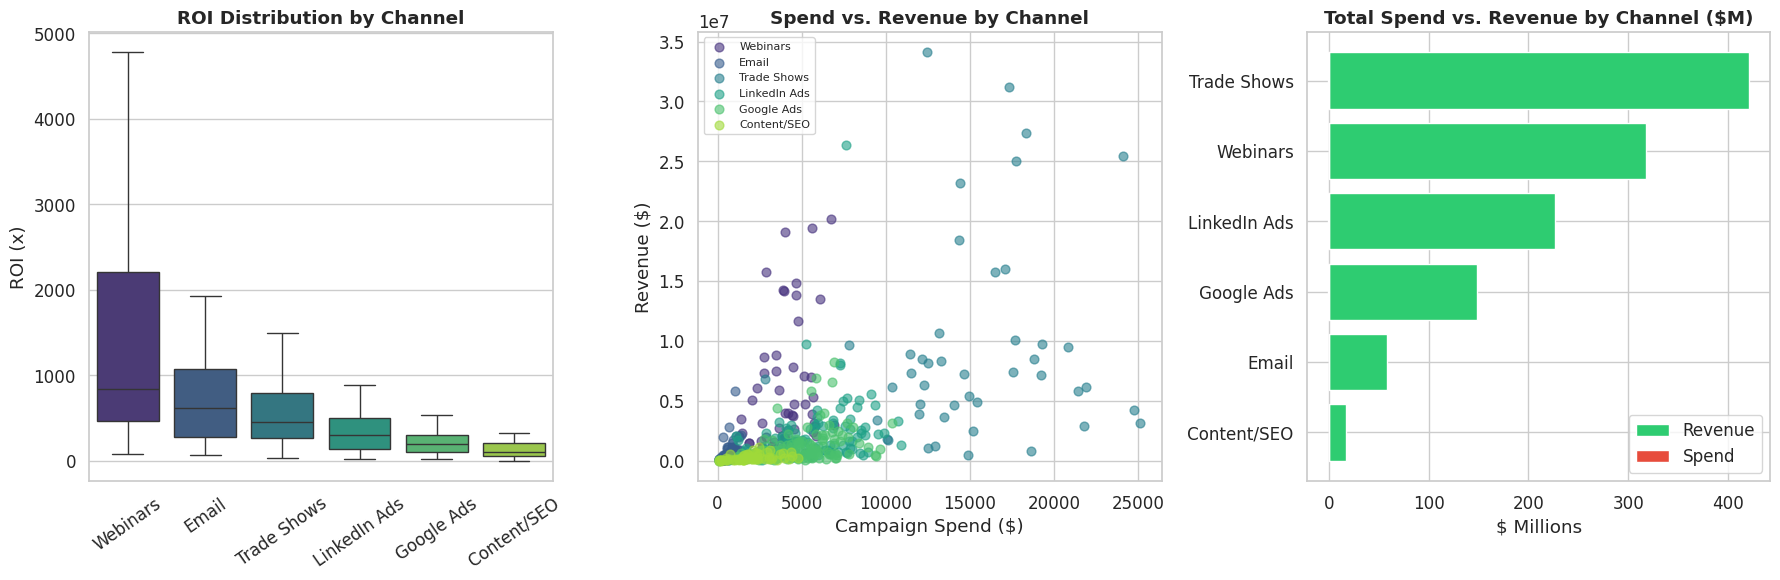

Figure saved: data/channel_overview.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. ROI distribution by channel (box plot)
channel_order = df.groupby('channel')['roi'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='channel', y='roi', order=channel_order, ax=axes[0],
            showfliers=False, palette='viridis')
axes[0].set_title('ROI Distribution by Channel', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('ROI (x)')
axes[0].tick_params(axis='x', rotation=35)

# 2. Spend vs. Revenue scatter
colors = sns.color_palette('viridis', n_colors=len(df['channel'].unique()))
for idx, ch in enumerate(channel_order):
    subset = df[df['channel'] == ch]
    axes[1].scatter(subset['spend_usd'], subset['revenue_usd'],
                    label=ch, alpha=0.6, s=40, color=colors[idx])
axes[1].set_title('Spend vs. Revenue by Channel', fontweight='bold')
axes[1].set_xlabel('Campaign Spend ($)')
axes[1].set_ylabel('Revenue ($)')
axes[1].legend(fontsize=8, loc='upper left')

# 3. Aggregate channel performance (total spend vs. total revenue)
agg = df.groupby('channel').agg(total_spend=('spend_usd','sum'), total_revenue=('revenue_usd','sum')).reset_index()
x_pos = range(len(agg))
agg_sorted = agg.sort_values('total_revenue', ascending=True)
axes[2].barh(agg_sorted['channel'], agg_sorted['total_revenue'] / 1e6, color='#2ecc71', label='Revenue')
axes[2].barh(agg_sorted['channel'], -agg_sorted['total_spend'] / 1e6, color='#e74c3c', label='Spend')
axes[2].set_title('Total Spend vs. Revenue by Channel ($M)', fontweight='bold')
axes[2].set_xlabel('$ Millions')
axes[2].legend()

plt.tight_layout()
plt.savefig('data/channel_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: data/channel_overview.png')

## 4. Statistical Testing: Are Channel ROI Differences Significant?

ROI distributions are typically right-skewed, so we use the **Kruskal-Wallis H-test** (non-parametric alternative to one-way ANOVA) followed by **Dunn's post-hoc test** with Bonferroni correction.

In [7]:
# Check normality assumption (Shapiro-Wilk per channel)
print('=== Shapiro-Wilk Normality Test (ROI by Channel) ===')
print(f'{"Channel":<15} {"W-stat":>8} {"p-value":>10} {"Normal?":>10}')
print('-' * 48)
for ch in channel_order:
    sample = df[df['channel'] == ch]['roi']
    w_stat, p_val = stats.shapiro(sample[:50])  # Shapiro-Wilk limited to n=50 sample
    normal = 'Yes' if p_val > 0.05 else 'No'
    print(f'{ch:<15} {w_stat:>8.4f} {p_val:>10.4f} {normal:>10}')

print('\n→ ROI distributions are non-normal, confirming non-parametric test is appropriate.')

=== Shapiro-Wilk Normality Test (ROI by Channel) ===
Channel           W-stat    p-value    Normal?
------------------------------------------------
Webinars          0.8513     0.0000         No
Email             0.8015     0.0000         No
Trade Shows       0.8117     0.0000         No
LinkedIn Ads      0.7499     0.0000         No
Google Ads        0.7909     0.0000         No
Content/SEO       0.7919     0.0000         No

→ ROI distributions are non-normal, confirming non-parametric test is appropriate.


In [8]:
# Kruskal-Wallis H-test
channel_groups = [group['roi'].values for _, group in df.groupby('channel')]
h_stat, kw_pval = kruskal(*channel_groups)

# Effect size: eta-squared for Kruskal-Wallis
n = len(df)
k = df['channel'].nunique()
eta_sq = (h_stat - k + 1) / (n - k)

print('=== Kruskal-Wallis H-Test: ROI ~ Channel ===')
print(f'H-statistic: {h_stat:.3f}')
print(f'p-value:     {kw_pval:.2e}')
print(f'eta-squared: {eta_sq:.4f} ({"small" if eta_sq < 0.06 else "medium" if eta_sq < 0.14 else "large"} effect)')
print(f'\n→ {"Significant" if kw_pval < 0.05 else "Not significant"} difference in ROI across channels (α=0.05).')

=== Kruskal-Wallis H-Test: ROI ~ Channel ===
H-statistic: 179.464
p-value:     6.96e-37
eta-squared: 0.3532 (large effect)

→ Significant difference in ROI across channels (α=0.05).


In [9]:
# Dunn's post-hoc pairwise comparisons with Bonferroni correction
from itertools import combinations

channels_list = sorted(df['channel'].unique())
pairs = list(combinations(channels_list, 2))
n_comparisons = len(pairs)
alpha_bonf = 0.05 / n_comparisons

print(f'=== Pairwise Mann-Whitney U Tests (Bonferroni α = {alpha_bonf:.4f}) ===')
print(f'{"Channel A":<15} {"Channel B":<15} {"U-stat":>10} {"p-value":>10} {"Significant":>12} {"Cohen d":>10}')
print('-' * 75)

significant_pairs = []
for ch_a, ch_b in pairs:
    a = df[df['channel'] == ch_a]['roi']
    b = df[df['channel'] == ch_b]['roi']
    u_stat, p_val = mannwhitneyu(a, b, alternative='two-sided')
    
    # Cohen's d
    pooled_std = np.sqrt((a.var() + b.var()) / 2)
    cohens_d = (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0
    
    sig = '***' if p_val < alpha_bonf else ''
    if p_val < alpha_bonf:
        significant_pairs.append((ch_a, ch_b, cohens_d))
    print(f'{ch_a:<15} {ch_b:<15} {u_stat:>10.0f} {p_val:>10.4f} {sig:>12} {cohens_d:>10.3f}')

print(f'\n→ {len(significant_pairs)} of {n_comparisons} pairs show statistically significant ROI differences.')

=== Pairwise Mann-Whitney U Tests (Bonferroni α = 0.0033) ===
Channel A       Channel B           U-stat    p-value  Significant    Cohen d
---------------------------------------------------------------------------
Content/SEO     Email                  570     0.0000          ***     -0.994
Content/SEO     Google Ads            2963     0.0023          ***     -0.453
Content/SEO     LinkedIn Ads          1609     0.0000          ***     -0.726
Content/SEO     Trade Shows            414     0.0000          ***     -1.131
Content/SEO     Webinars               185     0.0000          ***     -1.362
Email           Google Ads            9803     0.0000          ***      0.853
Email           LinkedIn Ads          7165     0.0000          ***      0.590
Email           Trade Shows           2459     0.1868                   0.224
Email           Webinars              2027     0.0037                  -0.483
Google Ads      LinkedIn Ads          4960     0.0001          ***     -0.433
Goog

## 5. Segment × Channel Interaction Analysis

Does the *best* channel depend on which customer segment you're targeting? We use a two-way ANOVA on log-transformed ROI to test for interaction effects.

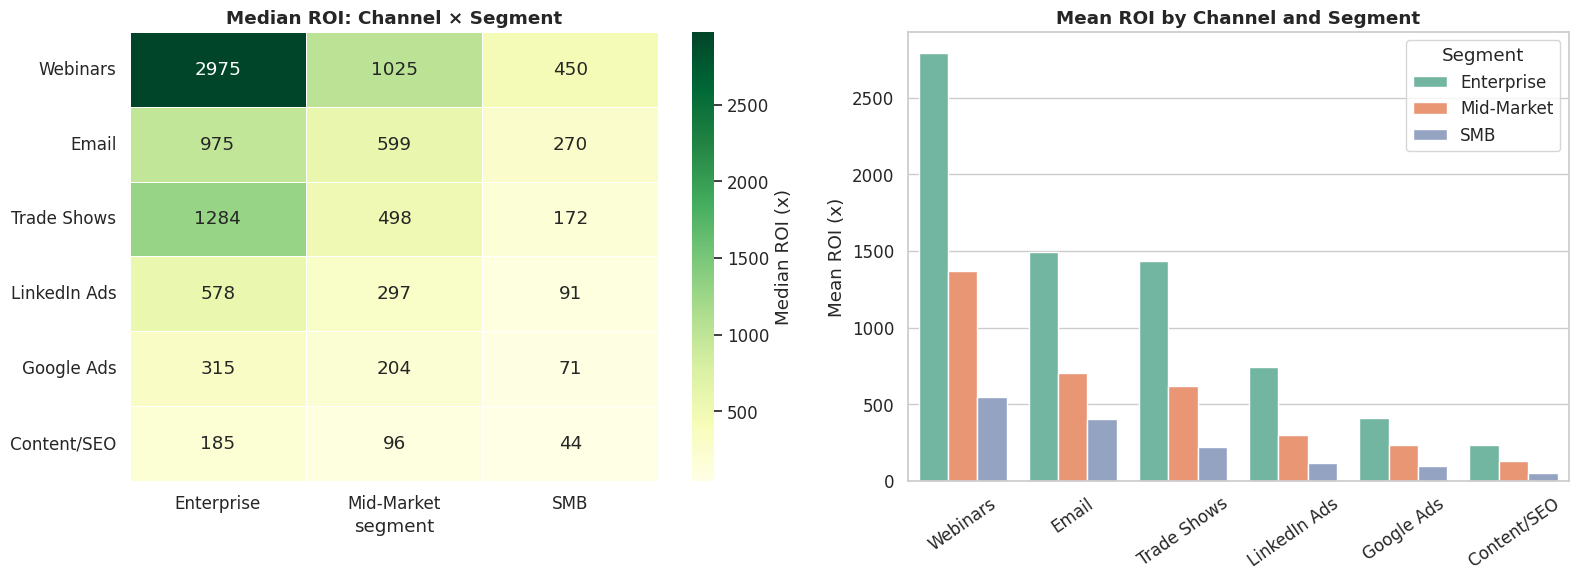

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: median ROI by channel × segment
pivot_roi = df.pivot_table(values='roi', index='channel', columns='segment',
                           aggfunc='median').reindex(channel_order)
sns.heatmap(pivot_roi, annot=True, fmt='.0f', cmap='YlGn', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Median ROI (x)'})
axes[0].set_title('Median ROI: Channel × Segment', fontweight='bold')
axes[0].set_ylabel('')

# Grouped bar chart: mean ROI by channel and segment
segment_channel = df.groupby(['channel', 'segment'])['roi'].mean().reset_index()
sns.barplot(data=segment_channel, x='channel', y='roi', hue='segment',
            order=channel_order, ax=axes[1], palette='Set2')
axes[1].set_title('Mean ROI by Channel and Segment', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean ROI (x)')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='Segment')

plt.tight_layout()
plt.savefig('data/segment_channel_interaction.png', bbox_inches='tight', dpi=150)
plt.show()

In [11]:
# Two-way ANOVA using statsmodels for interaction test
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Log-transform ROI to improve normality (add 1 to handle edge cases)
df['log_roi'] = np.log1p(df['roi'].clip(lower=0))

model = ols('log_roi ~ C(channel) * C(segment)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Calculate eta-squared
anova_table['eta_sq'] = anova_table['sum_sq'] / anova_table['sum_sq'].sum()

print('=== Two-Way ANOVA: log(ROI) ~ Channel × Segment ===')
print(anova_table.round(4))
print(f'\nModel R²: {model.rsquared:.4f}')
print(f'Adjusted R²: {model.rsquared_adj:.4f}')

=== Two-Way ANOVA: log(ROI) ~ Channel × Segment ===
                         sum_sq     df         F  PR(>F)  eta_sq
C(channel)             259.5117    5.0   98.1651  0.0000  0.3796
C(segment)             163.4738    2.0  154.5925  0.0000  0.2391
C(channel):C(segment)    5.7535   10.0    1.0882  0.3693  0.0084
Residual               254.8454  482.0       NaN     NaN  0.3728

Model R²: 0.6102
Adjusted R²: 0.5964


## 6. ROI Drivers: Regression Analysis

What campaign-level factors predict higher ROI? We fit an OLS regression with channel, segment, duration, and spend efficiency features.

In [12]:
# Prepare regression features
df['log_spend'] = np.log1p(df['spend_usd'])
df['log_impressions'] = np.log1p(df['impressions'])

reg_model = ols(
    'log_roi ~ log_spend + log_impressions + ctr + duration_days + '
    'C(channel, Treatment(reference="Google Ads")) + '
    'C(segment, Treatment(reference="Mid-Market")) + '
    'C(region)',
    data=df.dropna(subset=['ctr'])
).fit()

print('=== OLS Regression: log(ROI) Drivers ===')
print(f'R²: {reg_model.rsquared:.4f} | Adj R²: {reg_model.rsquared_adj:.4f}')
print(f'F-stat: {reg_model.fvalue:.2f} | p(F): {reg_model.f_pvalue:.2e}')
print(f'N: {int(reg_model.nobs)}')
print('\n--- Coefficients ---')

coef_df = pd.DataFrame({
    'coefficient': reg_model.params,
    'std_error': reg_model.bse,
    'p_value': reg_model.pvalues,
}).round(4)
coef_df['significant'] = coef_df['p_value'].apply(lambda x: '***' if x < 0.001 else '**' if x < 0.01 else '*' if x < 0.05 else '')
coef_df

=== OLS Regression: log(ROI) Drivers ===
R²: 0.7402 | Adj R²: 0.7321
F-stat: 91.93 | p(F): 5.87e-131
N: 500

--- Coefficients ---


,coefficient,std_error,p_value,significant
Intercept,-1.5824,0.6171,0.0106,*
"C(channel, Treatment(reference=""Google Ads""))[T.Content/SEO]",-0.2917,0.1021,0.0045,**
"C(channel, Treatment(reference=""Google Ads""))[T.Email]",1.0296,0.1134,0.0000,***
"C(channel, Treatment(reference=""Google Ads""))[T.LinkedIn Ads]",0.8041,0.0858,0.0000,***
"C(channel, Treatment(reference=""Google Ads""))[T.Trade Shows]",1.5424,0.1236,0.0000,***
"C(channel, Treatment(reference=""Google Ads""))[T.Webinars]",1.0498,0.1181,0.0000,***
"C(segment, Treatment(reference=""Mid-Market""))[T.Enterprise]",0.6530,0.0661,0.0000,***
"C(segment, Treatment(reference=""Mid-Market""))[T.SMB]",-0.9487,0.0642,0.0000,***
C(region)[T.Midwest],-0.0352,0.0859,0.6819,
C(region)[T.Northeast],0.1347,0.0849,0.1132,


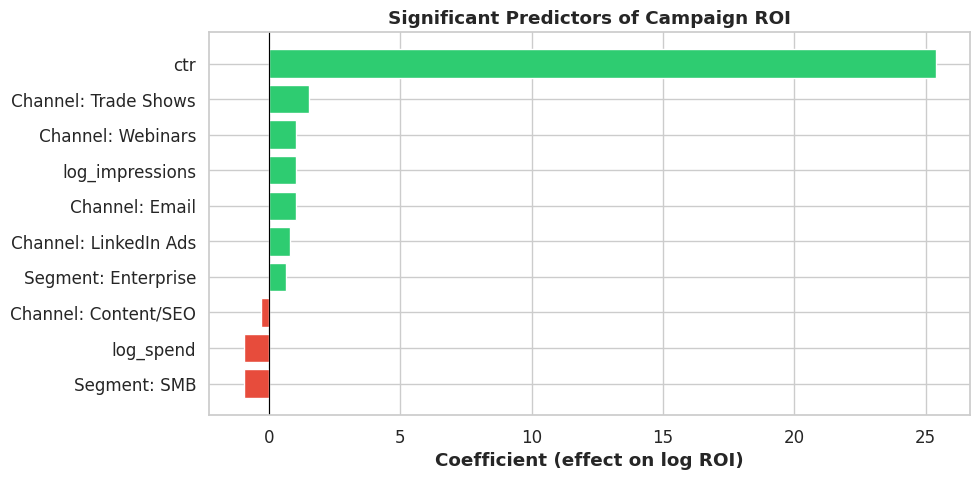

In [13]:
# Visualize significant coefficients
sig_coefs = coef_df[coef_df['p_value'] < 0.05].drop('Intercept', errors='ignore')
sig_coefs = sig_coefs.sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, max(4, len(sig_coefs) * 0.5)))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in sig_coefs['coefficient']]
ax.barh(range(len(sig_coefs)), sig_coefs['coefficient'], color=colors)
ax.set_yticks(range(len(sig_coefs)))

# Clean up coefficient names for display
labels = [name.replace('C(channel, Treatment(reference="Google Ads"))[T.', 'Channel: ')
              .replace('C(segment, Treatment(reference="Mid-Market"))[T.', 'Segment: ')
              .replace('C(region)[T.', 'Region: ')
              .replace(']', '')
          for name in sig_coefs.index]
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (effect on log ROI)', fontweight='bold')
ax.set_title('Significant Predictors of Campaign ROI', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('data/roi_predictors.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Funnel Efficiency Analysis

Beyond ROI, we examine how efficiently each channel moves prospects through the conversion funnel.

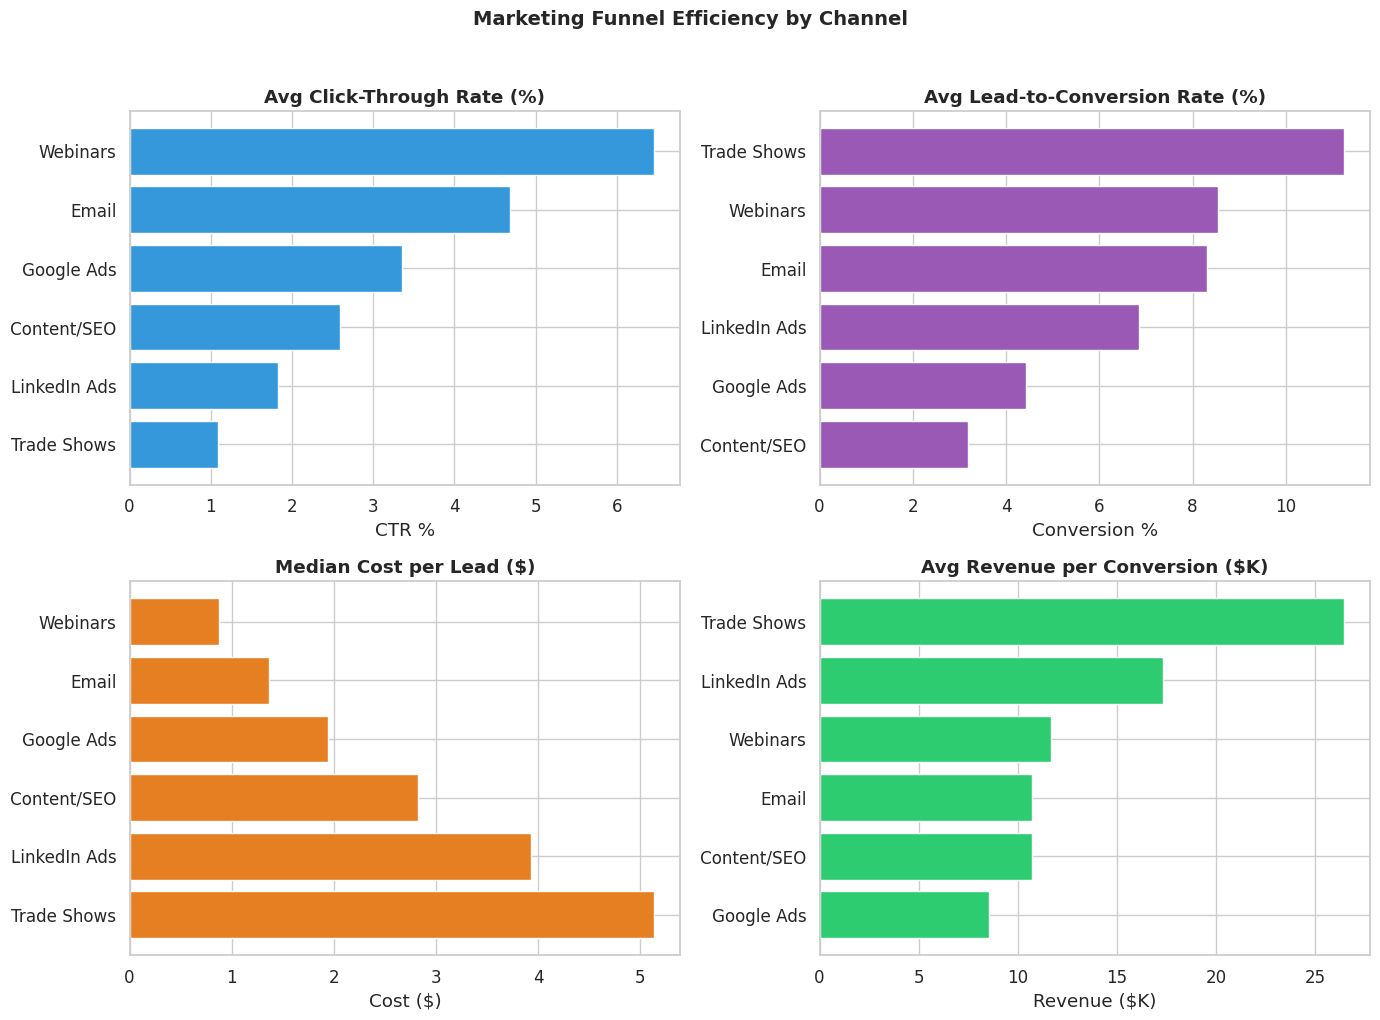

In [14]:
funnel_metrics = df.groupby('channel').agg(
    avg_ctr=('ctr', 'mean'),
    avg_lead_cvr=('lead_to_conversion_rate', 'mean'),
    median_cpl=('cost_per_lead', 'median'),
    median_cpc=('cost_per_conversion', 'median'),
    avg_rev_per_conv=('revenue_per_conversion', 'mean'),
).round(4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CTR by channel
funnel_sorted = funnel_metrics.sort_values('avg_ctr', ascending=True)
axes[0,0].barh(funnel_sorted.index, funnel_sorted['avg_ctr'] * 100, color='#3498db')
axes[0,0].set_title('Avg Click-Through Rate (%)', fontweight='bold')
axes[0,0].set_xlabel('CTR %')

# Lead-to-conversion rate
funnel_sorted = funnel_metrics.sort_values('avg_lead_cvr', ascending=True)
axes[0,1].barh(funnel_sorted.index, funnel_sorted['avg_lead_cvr'] * 100, color='#9b59b6')
axes[0,1].set_title('Avg Lead-to-Conversion Rate (%)', fontweight='bold')
axes[0,1].set_xlabel('Conversion %')

# Cost per lead
funnel_sorted = funnel_metrics.sort_values('median_cpl', ascending=False)
axes[1,0].barh(funnel_sorted.index, funnel_sorted['median_cpl'], color='#e67e22')
axes[1,0].set_title('Median Cost per Lead ($)', fontweight='bold')
axes[1,0].set_xlabel('Cost ($)')

# Revenue per conversion
funnel_sorted = funnel_metrics.sort_values('avg_rev_per_conv', ascending=True)
axes[1,1].barh(funnel_sorted.index, funnel_sorted['avg_rev_per_conv'] / 1000, color='#2ecc71')
axes[1,1].set_title('Avg Revenue per Conversion ($K)', fontweight='bold')
axes[1,1].set_xlabel('Revenue ($K)')

plt.suptitle('Marketing Funnel Efficiency by Channel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/funnel_efficiency.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Key Findings & Recommendations

### Summary of Findings

In [15]:
# Generate summary statistics for the conclusion
top_channel = df.groupby('channel')['roi'].median().sort_values(ascending=False)
best_channel = top_channel.index[0]
worst_channel = top_channel.index[-1]

best_segment_combo = df.groupby(['channel', 'segment'])['roi'].median().sort_values(ascending=False).head(3)

print('╔══════════════════════════════════════════════════════════╗')
print('║           MARKETING CHANNEL ROI — KEY FINDINGS          ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Highest median ROI channel: {best_channel:<28}║')
print(f'║  Lowest median ROI channel:  {worst_channel:<28}║')
print(f'║  Kruskal-Wallis p-value:     {kw_pval:<28.2e}║')
print(f'║  Regression R²:             {reg_model.rsquared:<28.4f}║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  TOP 3 CHANNEL-SEGMENT COMBINATIONS (Median ROI):      ║')
for (ch, seg), roi_val in best_segment_combo.items():
    print(f'║    {ch} × {seg}: {roi_val:>8.0f}x{"":>18}║')
print('╚══════════════════════════════════════════════════════════╝')

print('\n--- STRATEGIC RECOMMENDATIONS ---')
print(f'1. INCREASE ALLOCATION to {best_channel} — consistently highest ROI across segments.')
print(f'2. RE-EVALUATE {worst_channel} spend — lowest ROI; consider shifting budget.')
print('3. SEGMENT-SPECIFIC STRATEGY: Tailor channel mix by customer segment for optimal returns.')
print('4. MONITOR CTR: Click-through rate is a leading indicator — channels with higher CTR')
print('   tend to produce stronger downstream conversions.')
print('5. CAMPAIGN DURATION: Longer campaigns show diminishing returns per dollar spent.')

╔══════════════════════════════════════════════════════════╗
║           MARKETING CHANNEL ROI — KEY FINDINGS          ║
╠══════════════════════════════════════════════════════════╣
║  Highest median ROI channel: Webinars                    ║
║  Lowest median ROI channel:  Content/SEO                 ║
║  Kruskal-Wallis p-value:     6.96e-37                    ║
║  Regression R²:             0.7402                      ║
╠══════════════════════════════════════════════════════════╣
║  TOP 3 CHANNEL-SEGMENT COMBINATIONS (Median ROI):      ║
║    Webinars × Enterprise:     2975x                  ║
║    Trade Shows × Enterprise:     1284x                  ║
║    Webinars × Mid-Market:     1025x                  ║
╚══════════════════════════════════════════════════════════╝

--- STRATEGIC RECOMMENDATIONS ---
1. INCREASE ALLOCATION to Webinars — consistently highest ROI across segments.
2. RE-EVALUATE Content/SEO spend — lowest ROI; consider shifting budget.
3. SEGMENT-SPECIFIC STRATEGY: Tai